Dataset Selection:

Data set Description described in another document “Drug Response Classification”

Task 1: Exploratory Data Analysis (EDA)

1. Load the dataset and perform fundamental data exploration.

2. Utilize histograms, box plots, or density plots to understand feature distributions.

3. Investigate feature correlations to discern relationships within the data.

Task 2: Data Preprocessing

1. Encode categorical variables if necessary.

2. Split the dataset into training and testing sets.

Task 3: Data Visualization

1. Employ scatter plots, pair plots, or relevant visualizations to comprehend feature distributions and relationships.

2. Visualize class distributions to gauge dataset balance or imbalance.

Task 4: SVM Implementation

1. Implement a basic SVM classifier using Python libraries like scikit-learn.

2. Train the SVM model on the training data.

3. Evaluate model performance on the testing data using appropriate metrics (e.g., accuracy, precision, recall, F1-score).

Task 5: Visualization of SVM Results

1. Visualize classification results on the testing data.

Task 6: Parameter Tuning and Optimization

1. Experiment with different SVM hyperparameters (e.g., kernel type, regularization parameter) to optimize performance.

Task 7: Comparison and Analysis

1. Compare SVM performance with various kernels (e.g., linear, polynomial, radial basis function).

2. Analyze SVM strengths and weaknesses for the dataset based on EDA and visualization results.

3. Discuss practical implications of SVM in real-world classification tasks.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("Pharma_Industry.csv")

df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [3]:
df.tail()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
495,-1.553759,0.506938,0.817890,-0.661245,-1.345393,0
496,0.551476,1.714321,0.340589,1.712558,-0.496315,1
497,-1.072743,-0.221137,0.239247,1.112924,-0.285838,1
498,1.661259,0.245759,-0.457096,0.633355,0.657413,0
499,-1.143726,0.715320,0.108560,-0.509787,-0.250704,1


In [4]:
df.shape

(500, 6)

In [5]:
df.describe()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


In [6]:
df.isnull().sum()

Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

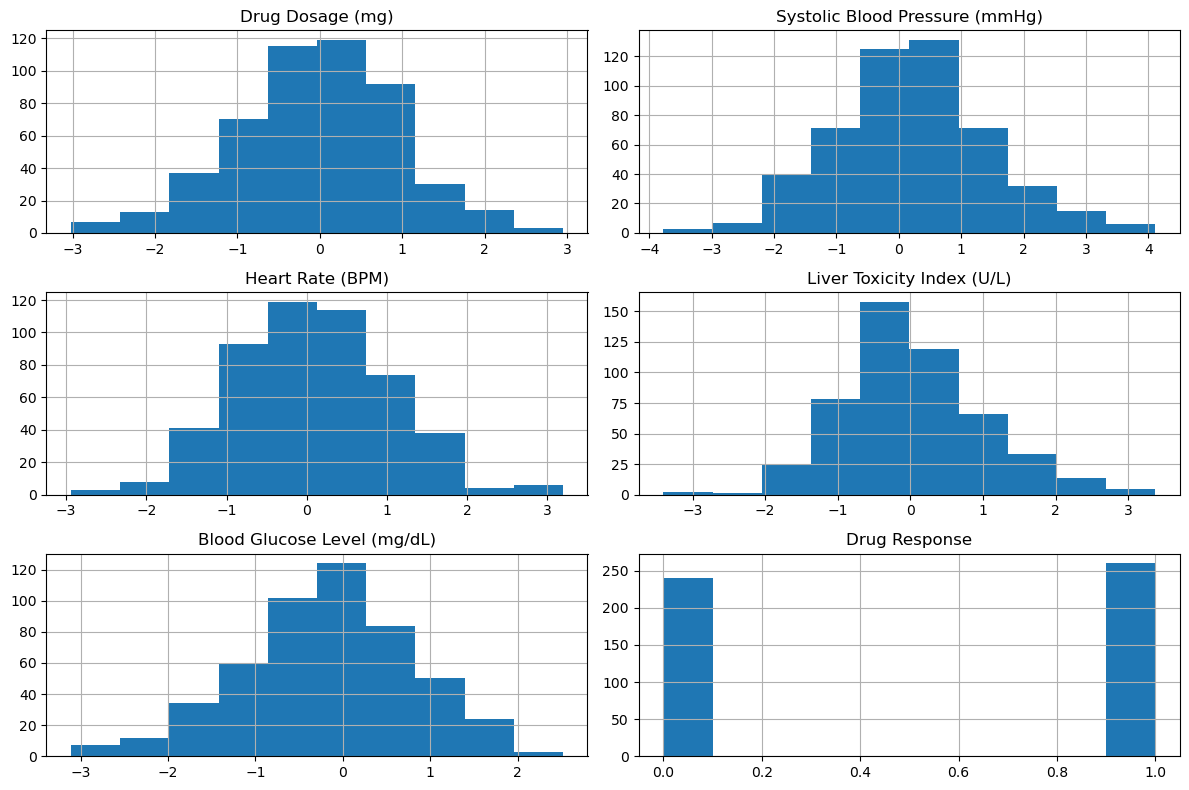

In [8]:
## Histogram
df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

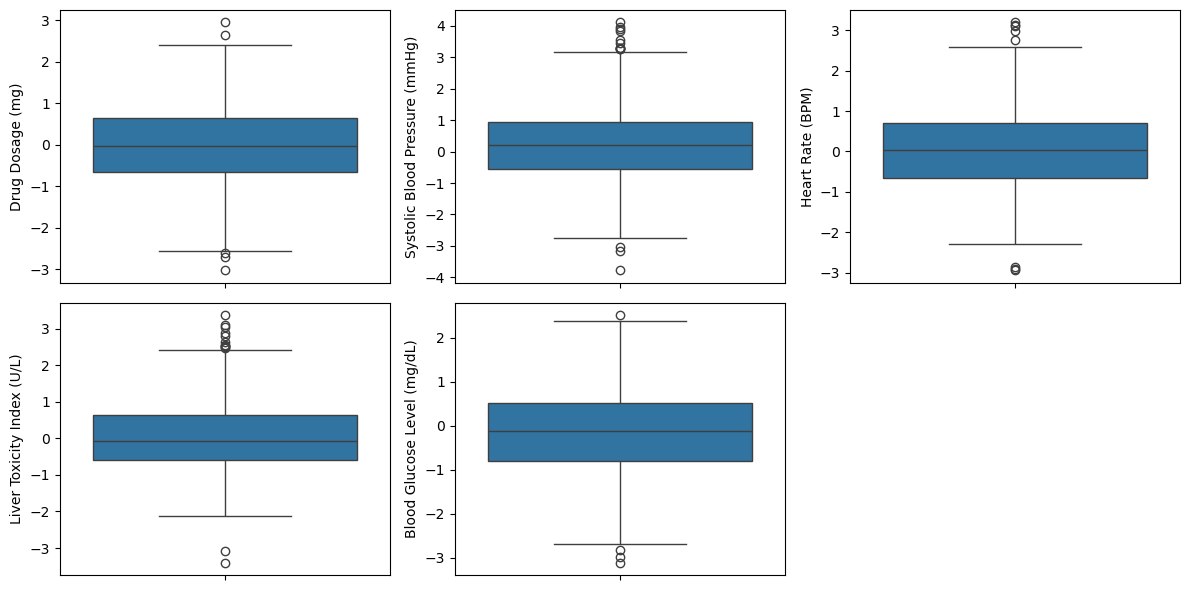

In [9]:
# Boxplot
plt.figure(figsize=(12,6))

for i,col in enumerate(df.columns[:-1]):
    plt.subplot(2,3,i+1)
    sns.boxplot(y=df[col])

plt.tight_layout()
plt.show()

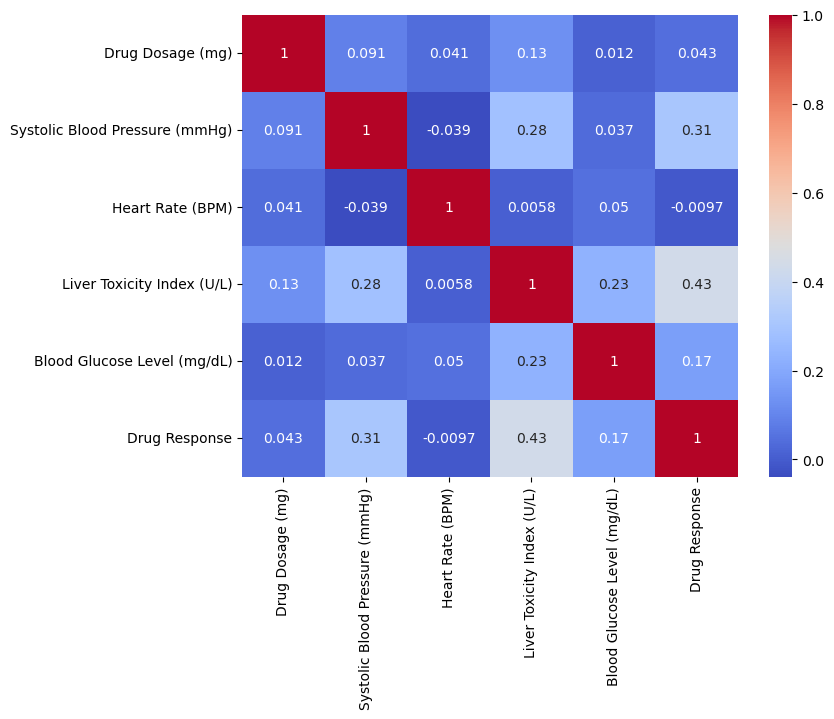

In [10]:
# HeatMap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.show()

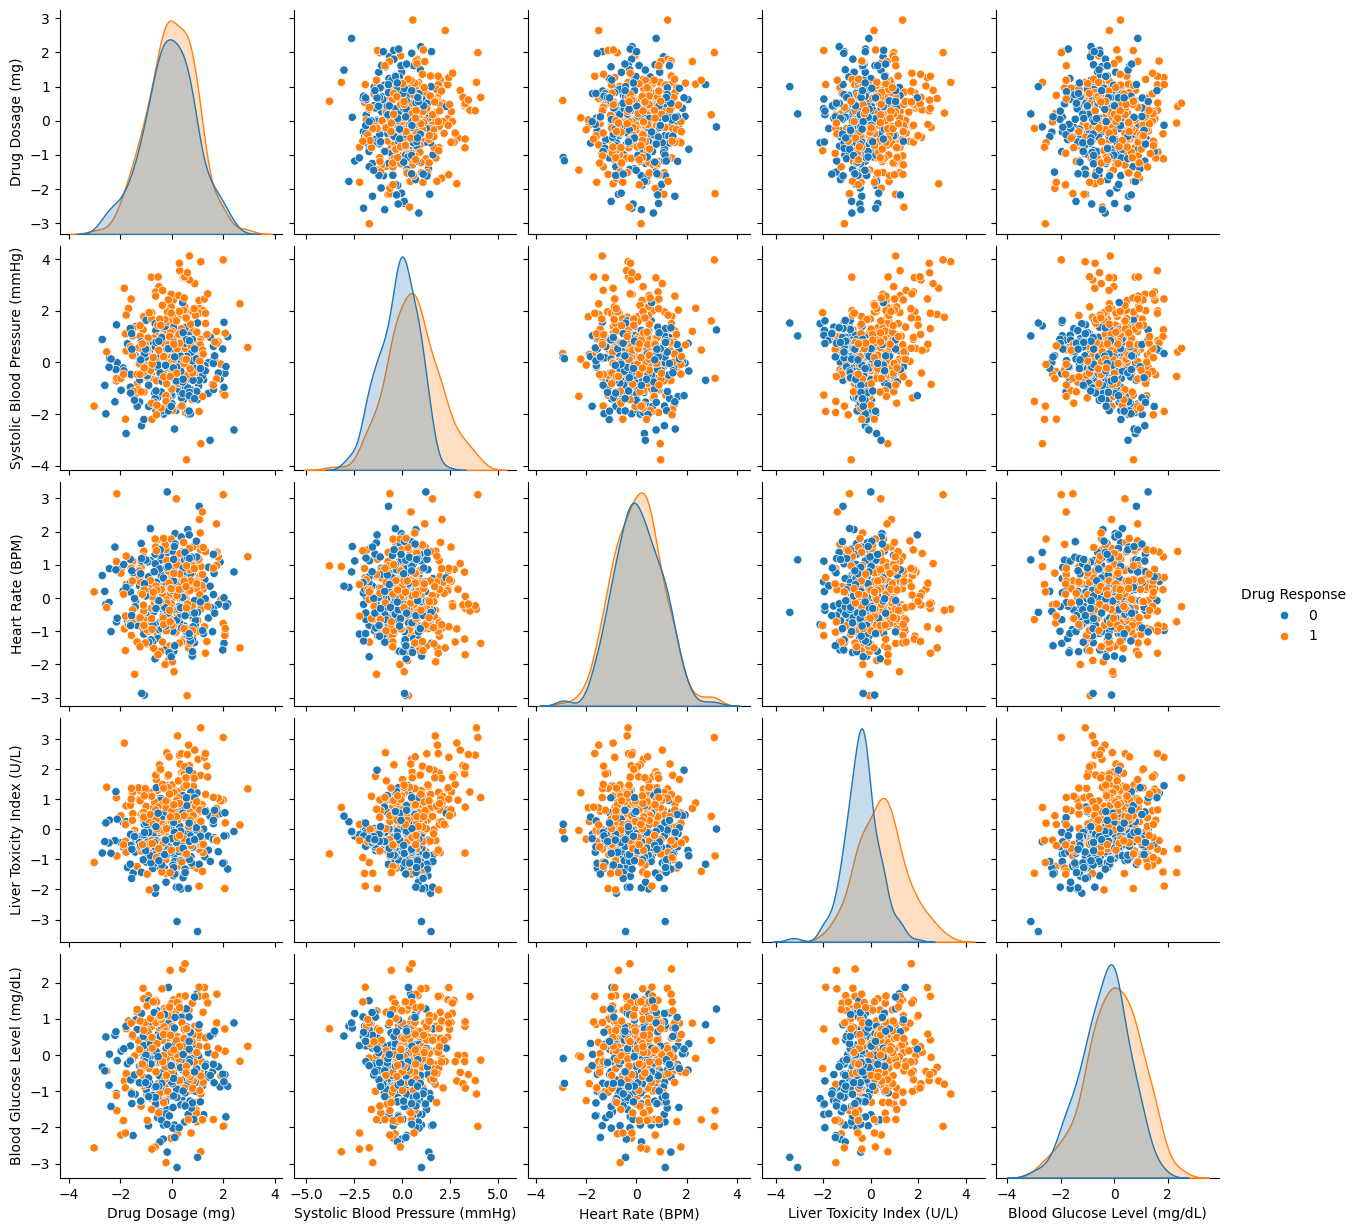

In [11]:
# Pairplot
sns.pairplot(df,hue="Drug Response")
plt.show()

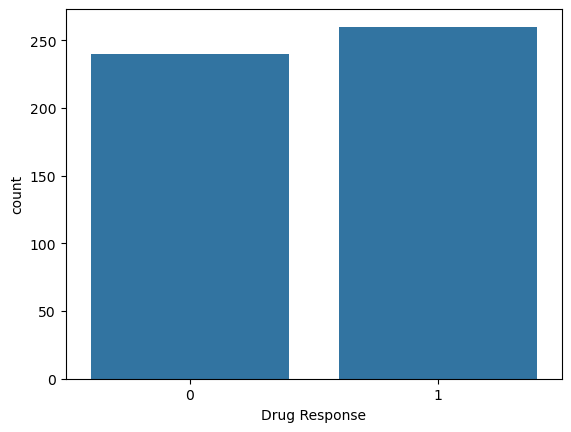

In [12]:
# Countplot
sns.countplot(x="Drug Response",data=df)
plt.show()

In [13]:
# Dropping the column
X=df.drop("Drug Response",axis=1)
y=df["Drug Response"]

In [14]:
# X_test , y_test
X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

In [15]:
scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [16]:
linear_model=SVC(kernel="linear")

linear_model.fit(X_train,y_train)

linear_pred=linear_model.predict(X_test)

In [17]:
print("Accuracy:",accuracy_score(y_test,linear_pred))
print("Precision:",precision_score(y_test,linear_pred))
print("Recall:",recall_score(y_test,linear_pred))
print("F1 Score:",f1_score(y_test,linear_pred))

Accuracy: 0.78
Precision: 0.84
Recall: 0.75
F1 Score: 0.7924528301886793


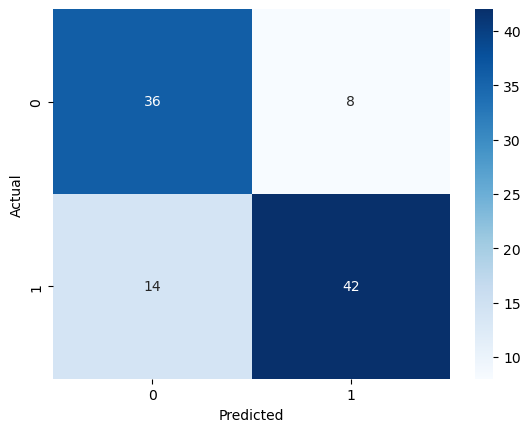

In [18]:
# Confusion Matrix
cm=confusion_matrix(y_test,linear_pred)

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [19]:
poly_model=SVC(kernel="poly")

poly_model.fit(X_train,y_train)

poly_pred=poly_model.predict(X_test)

print("Polynomial Accuracy:",accuracy_score(y_test,poly_pred))

Polynomial Accuracy: 0.71


In [20]:
rbf_model=SVC(kernel="rbf")

rbf_model.fit(X_train,y_train)

rbf_pred=rbf_model.predict(X_test)

print("RBF Accuracy:",accuracy_score(y_test,rbf_pred))

RBF Accuracy: 0.84


In [21]:
# Hyper Parameter tunning
param_grid={
    "C":[0.1,1,10,100],
    "gamma":[1,0.1,0.01,0.001],
    "kernel":["linear","rbf","poly"]
}

grid=GridSearchCV(
    SVC(),
    param_grid,
    cv=5
)

grid.fit(X_train,y_train)

,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': [1, 0.1, ...], 'kernel': ['linear', 'rbf', ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,100


In [22]:
print(grid.best_params_)
print(grid.best_score_)

{'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
0.7324999999999999


In [23]:
best_model=grid.best_estimator_

pred=best_model.predict(X_test)

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.77      0.91      0.83        44
           1       0.92      0.79      0.85        56

    accuracy                           0.84       100
   macro avg       0.84      0.85      0.84       100
weighted avg       0.85      0.84      0.84       100



In [24]:
results=pd.DataFrame({
    "Kernel":["Linear","Polynomial","RBF"],
    "Accuracy":[
        accuracy_score(y_test,linear_pred),
        accuracy_score(y_test,poly_pred),
        accuracy_score(y_test,rbf_pred)
    ]
})

results

,Kernel,Accuracy
0,Linear,0.78
1,Polynomial,0.71
2,RBF,0.84


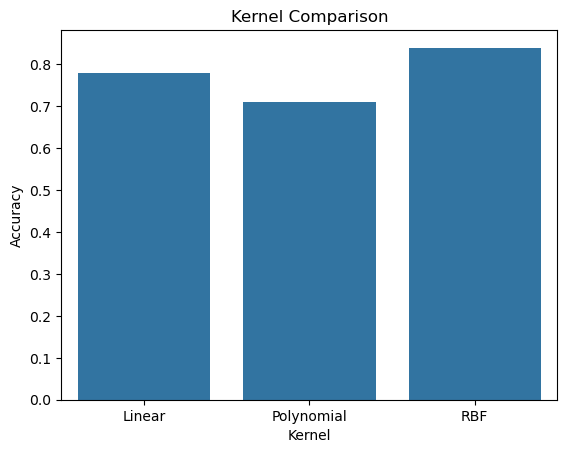

In [25]:
sns.barplot(x="Kernel",y="Accuracy",data=results)

plt.title("Kernel Comparison")

plt.show()

## Conclusion

#### Adavantages of svm 

Effective for binary classification.
    
Works well with high-dimensional datasets.
    
Handles non-linear decision boundaries using kernels.
    
Robust against overfitting with proper regularization.

#### Disadvantages

Training can be slow on very large datasets.
    
Sensitive to parameter selection.
    
Less interpretable than Decision Trees.

#### Real world application

Drug response prediction.
    
Cancer detection.
    
Image classification.
    
Spam email filtering.
    
Face recognition.